In [2]:
import torch 
import tiktoken
from torch import nn
from torch.utils.data import Dataset, DataLoader

### <b>Dataset and Data Loading Components<b>

In [3]:
# Custom dataset class for language modeling
class LLMDataset(Dataset):
    def __init__(self, text, tokenizer, context_length, stride):
        super().__init__()
        # Lists to store the input-target pairs
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

        # Create input-target pairs by sliding a window through the token sequence
        for i in range(0, len(token_ids)-context_length, stride):
            # Input chunk of context length
            input_chunk = token_ids[i:i+context_length]
            # Target chunk shifted by 1 token to predict the next token
            target_chunk = token_ids[i+1: i+context_length+1]
            # Convert lists to tensor format for PyTorch
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        # Returns the total number of examples in the dataset
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        # Returns the input_id and target_id at the requested index
        return self.input_ids[idx], self.target_ids[idx]

In [4]:
# Function to create a DataLoader for language model training
def create_dataloader_v1(txt, batch_size=4, context_length=256, 
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):
    """
    Creates a DataLoader for training language models
    
    Parameters:
    - batch_size: Number of sequences in each batch
    - context_length: Maximum sequence length for input and target
    - stride: Step size between consecutive training examples
    - shuffle: Whether to randomly shuffle the dataset
    - drop_last: Whether to drop the last incomplete batch
    - num_workers: Number of parallel workers for data loading
    """
    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset using our custom dataset class
    dataset = LLMDataset(txt, tokenizer, context_length, stride)

    # Create and return the dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

### **Model Architecture Components**

In [5]:
# Custom Layer Normalization implementation
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5  # Small epsilon for numerical stability
        self.scale = nn.Parameter(torch.ones(emb_dim))  # Learnable scaling parameter
        self.shift = nn.Parameter(torch.zeros(emb_dim))  # Learnable shift parameter

    def forward(self, x):
        # Calculate mean and variance along the embedding dimension
        mean = x.mean(dim=-1, keepdim=True)  # keepdim=True preserves tensor dimensions
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        
        # Normalize the input tensor
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        
        # Apply learnable scale and shift parameters
        return self.scale * norm_x + self.shift

In [6]:
# Multi-head self-attention mechanism
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Dimension per attention head

        # Linear projections for queries, keys, and values
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        
        # Final output projection
        self.out_proj = nn.Linear(d_out, d_out)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)
        
        # Register causal mask as a buffer (not a parameter)
        # This creates an upper triangular matrix to mask future positions
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        # Linear projections
        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Reshape tensors for multi-head attention
        # (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) 
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose to get (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute attention scores (dot product between queries and keys)
        attn_scores = queries @ keys.transpose(2, 3)  # Shape: (b, num_heads, num_tokens, num_tokens)

        # Apply causal mask to enforce autoregressive property
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)  # Fill masked positions with negative infinity
        
        # Apply scaling factor and softmax to get attention weights
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)  # Apply dropout to attention weights

        # Apply attention weights to values
        context_vec = (attn_weights @ values).transpose(1, 2)  # Shape: (b, num_tokens, num_heads, head_dim)
        
        # Combine all heads into a single tensor
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        
        # Final linear projection
        context_vec = self.out_proj(context_vec)

        return context_vec

In [7]:
# GELU activation function (used in transformers instead of ReLU)
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # Approximation of the Gaussian Error Linear Unit function
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [8]:
# Feed-forward neural network used in transformer blocks
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            # First layer expands dimension by factor of 4
            nn.Linear(cfg['emb_dim'], 4*cfg['emb_dim']),
            GELU(),  # Apply GELU activation
            # Second layer projects back to original embedding dimension
            nn.Linear(4 * cfg['emb_dim'], cfg['emb_dim'])
        )
    
    def forward(self, x):
        return self.layers(x)

In [9]:
# Complete transformer block with attention, feed-forward, and residual connections
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # Multi-head self-attention layer
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        # Feed-forward layer
        self.ff = FeedForward(cfg)
        
        # Layer normalization layers (applied before attention and feed-forward)
        self.norm1 = LayerNorm(cfg['emb_dim'])
        self.norm2 = LayerNorm(cfg['emb_dim'])
        
        # Dropout for residual connections
        self.drop_shortcut = nn.Dropout(cfg['drop_rate'])

    def forward(self, x):
        # First sub-block: attention with residual connection
        shortcut = x
        x = self.norm1(x)  # Pre-normalization
        x = self.att(x)    # Self-attention
        x = self.drop_shortcut(x)  # Apply dropout
        x = x + shortcut   # Add residual connection

        # Second sub-block: feed-forward with residual connection
        shortcut = x
        x = self.norm2(x)  # Pre-normalization
        x = self.ff(x)     # Feed-forward network
        x = self.drop_shortcut(x)  # Apply dropout
        x = x + shortcut   # Add residual connection

        return x

### **Complete Language Model Architecture**

In [10]:
# Full language model combining all components
class LLMModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # Token embeddings
        self.token_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        
        # Positional embeddings
        self.positional_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        
        # Embedding dropout
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Stack of transformer blocks
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        
        # Final layer normalization
        self.final_norm = LayerNorm(cfg["emb_dim"])
        
        # Output projection to vocabulary
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        
        # Get token embeddings
        token_embeds = self.token_emb(in_idx)
        
        # Get position embeddings for each position in the sequence
        pos_embeds = self.positional_emb(torch.arange(seq_len, device=in_idx.device))
        
        # Add token and position embeddings
        x = token_embeds + pos_embeds
        
        # Apply embedding dropout
        x = self.drop_emb(x)
        
        # Pass through transformer blocks
        x = self.trf_blocks(x)
        
        # Apply final normalization and project to vocabulary size
        x = self.final_norm(x)
        logits = self.out_head(x)
        
        return logits

### **Text Generation Functions**

In [11]:
# Basic text generation function
def generate_text_simple(model, idx, max_new_tokens, context_size):
    """
    Generate text using a simple greedy decoding strategy
    
    Parameters:
    - model: The language model
    - idx: Starting token indices
    - max_new_tokens: Number of tokens to generate
    - context_size: Maximum context length the model can process
    
    Returns:
    - Full sequence including generated tokens
    """
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        
        # Crop the context if it exceeds the supported context size
        idx_cond = idx[:, -context_size:]
        
        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)

        # Get the token with highest probability
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)

        # Append the new token to the sequence
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [12]:
# Advanced text generation with temperature and top-k sampling
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    """
    Generate text with temperature control and top-k sampling
    
    Parameters:
    - model: The language model
    - idx: Starting token indices
    - max_new_tokens: Number of tokens to generate
    - context_size: Maximum context length the model can process
    - temperature: Controls randomness (0=deterministic, >0=random)
    - top_k: If set, only sample from the top k most likely tokens
    - eos_id: If set, stop generation when this token is produced
    
    Returns:
    - Full sequence including generated tokens
    """
    for _ in range(max_new_tokens):
        # Get current context within the context window
        idx_cond = idx[:, -context_size:]
        
        with torch.no_grad():
            logits = model(idx_cond)
        
        # Focus on the predictions for the last token
        logits = logits[:, -1, :]

        # Apply top-k filtering if specified
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            # Find the smallest value in the top-k
            min_val = top_logits[:, -1]
            # Set all logits below this value to -infinity
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # Apply temperature scaling for controlling randomness
        if temperature > 0.0:
            logits = logits / temperature

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            # For temperature=0, use greedy selection (most likely token)
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        # Stop generation if eos_id is encountered
        if idx_next.item() == eos_id and eos_id is not None:
            break

        # Append the new token to the sequence
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [13]:
# Calculate loss for a single batch
def calc_loss_batch(input_batch, target_batch, model, device):
    """
    Calculate cross-entropy loss for a single batch
    
    Parameters:
    - input_batch: Input token IDs (batch_size, seq_len)
    - target_batch: Target token IDs (batch_size, seq_len)
    - model: The language model
    - device: Device to run calculation on (CPU or GPU)
    
    Returns:
    - Loss value
    """
    # Move input and target to the specified device
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    
    # Get predictions from the model
    logits = model(input_batch)
    
    # Calculate cross-entropy loss
    # Flatten the logits and targets for the cross-entropy function
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    
    return loss

In [14]:
# Calculate average loss for an entire data loader
def calc_loss_loader(data_loader, model, device, num_batches=None):
    """
    Calculate average loss over multiple batches
    
    Parameters:
    - data_loader: DataLoader containing batches of data
    - model: The language model
    - device: Device to run calculation on (CPU or GPU)
    - num_batches: Number of batches to process (None = all batches)
    
    Returns:
    - Average loss value
    """
    total_loss = 0.0
    
    # Handle empty data loader
    if len(data_loader) == 0:
        return float("nan")
    
    # Determine number of batches to process
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        # Ensure num_batches doesn't exceed available batches
        num_batches = min(num_batches, len(data_loader))
    
    # Process each batch
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
            
    # Return average loss
    return total_loss / num_batches

In [15]:
# Utility functions for token conversion
def text_to_token_ids(text, tokenizer):
    """
    Convert text to token IDs
    
    Parameters:
    - text: Input text string
    - tokenizer: Tokenizer to use for encoding
    
    Returns:
    - Tensor of token IDs with batch dimension
    """
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # Add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    """
    Convert token IDs back to text
    
    Parameters:
    - token_ids: Tensor of token IDs
    - tokenizer: Tokenizer to use for decoding
    
    Returns:
    - Decoded text string
    """
    flat = token_ids.squeeze(0)  # Remove batch dimension
    return tokenizer.decode(flat.tolist())

In [16]:
# Model evaluation function
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    """
    Evaluate model performance on training and validation sets
    
    Parameters:
    - model: The language model
    - train_loader: DataLoader for training data
    - val_loader: DataLoader for validation data
    - device: Device to run evaluation on
    - eval_iter: Number of batches to evaluate
    
    Returns:
    - train_loss: Average loss on training data
    - val_loss: Average loss on validation data
    """
    # Switch model to evaluation mode
    model.eval()
    
    # Calculate losses without gradient tracking
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    
    # Switch model back to training mode
    model.train()
    
    return train_loss, val_loss

In [17]:
# Generate and print a text sample during training
def generate_and_print_sample(model, tokenizer, device, start_context):
    """
    Generate and print a text sample during training
    
    Parameters:
    - model: The language model
    - tokenizer: Tokenizer for encoding/decoding
    - device: Device to run generation on
    - start_context: Starting text prompt
    """
    # Switch to evaluation mode
    model.eval()
    
    # Get context size from model
    context_size = model.positional_emb.weight.shape[0]
    
    # Encode the starting context
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    
    # Generate text
    with torch.no_grad():
        token_ids = generate(
            model=model,
            idx=encoded,
            max_new_tokens=50,
            context_size=context_size,
            top_k=25,
            temperature=1.4
        )
    
    # Decode generated text
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    
    # Print generated text
    print(decoded_text.replace("\n", " "))  # Compact print format
    
    # Switch back to training mode
    model.train()

In [18]:
# Complete training function
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    """
    Train the language model
    
    Parameters:
    - model: The language model to train
    - train_loader: DataLoader for training data
    - val_loader: DataLoader for validation data
    - optimizer: Optimizer for parameter updates
    - device: Device to train on
    - num_epochs: Number of training epochs
    - eval_freq: Steps between evaluations
    - eval_iter: Number of batches to evaluate
    - start_context: Starting text for generation samples
    - tokenizer: Tokenizer for encoding/decoding
    
    Returns:
    - train_losses: List of training losses
    - val_losses: List of validation losses
    - tokens_seen: Number of tokens processed at each evaluation
    """
    # Initialize tracking variables
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        # Process each batch in the training data
        for input_batch, target_batch in train_loader:
            # Reset gradients
            optimizer.zero_grad()
            
            # Calculate loss
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            
            # Backpropagate gradients
            loss.backward()
            
            # Update weights
            optimizer.step()
            
            # Track progress
            tokens_seen += input_batch.numel()  # Count tokens processed
            global_step += 1

            # Periodic evaluation
            if global_step % eval_freq == 0: 
                # Evaluate on training and validation data
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                
                # Record metrics
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                
                # Print progress
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Generate sample text after each epoch
        generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, track_tokens_seen

### **Data Preparation and Model Configuration**

In [19]:
# Download and prepare the dataset
import os
import urllib.request

# File path for the dataset
file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

# Download the dataset if it doesn't exist
if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode('utf-8')
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    # Read the dataset if it already exists
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

# Model configuration (GPT-2 small-sized model)
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size (GPT-2 tokenizer)
    "context_length": 256,  # Maximum sequence length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of transformer layers
    "drop_rate": 0.1,       # Dropout rate for regularization
    "qkv_bias": False       # Whether to use bias in query-key-value projections
}

# Initialize the model and tokenizer
model = LLMModel(GPT_CONFIG_124M)
tokenizer = tiktoken.get_encoding('gpt2')

# Print dataset statistics
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [20]:
# Split data into training and validation sets
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

# Set random seed for reproducibility
torch.manual_seed(123)

# Create data loaders
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    context_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    context_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

# Verify data loader configurations
if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Warning: Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Warning: Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

# Print data loader shapes
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)
    break  # Just print the first batch

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)
    break  # Just print the first batch

# Print data loader sizes
print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in val_loader: {len(val_loader)}")

# Count total tokens in the datasets
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])
Number of batches in train_loader: 9
Number of batches in val_loader: 1
Training tokens: 4608
Validation tokens: 512
All tokens: 5120


### **Model Training and Evaluation**

In [21]:
# Set up the device for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize the model
model = LLMModel(GPT_CONFIG_124M)

# Move model to device
model.to(device)

# Calculate initial loss values
torch.manual_seed(123)  # For reproducibility

with torch.no_grad():  # Disable gradient tracking for efficiency
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Initial training loss:", train_loss)
print("Initial validation loss:", val_loss)

Using device: cpu
Initial training loss: 10.995999654134115
Initial validation loss: 10.984992027282715


In [22]:
# Train the model
import time

# Start timing
start_time = time.time()

# Reset random seed for reproducibility
torch.manual_seed(123)

# Initialize a new model
model = LLMModel(GPT_CONFIG_124M)
model.to(device)

# Initialize optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

# Training parameters
num_epochs = 10

# Train the model
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

# End timing
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.783, Val loss 9.927
Ep 1 (Step 000005): Train loss 7.985, Val loss 8.335
Every effort moves you he   and-- the in.. of;       ". a my to you.    of. " of was of.      " of the I was the  
Ep 2 (Step 000010): Train loss 6.811, Val loss 7.053
Ep 2 (Step 000015): Train loss 6.095, Val loss 6.622
Every effort moves you, and a on and. he.    " I the to a me" to, was of it he his, and I my him him of the't, it to was that it and the me, to's the he have
Ep 3 (Step 000020): Train loss 13.419, Val loss 13.403
Ep 3 (Step 000025): Train loss 5.621, Val loss 6.471
Every effort moves you to my's his a Mrs.  He of, and him himburn, it.   ", itburn it the, when a in the of to to his a. I, the up's." "'t, when
Ep 4 (Step 000030): Train loss 5.379, Val loss 6.484
Ep 4 (Step 000035): Train loss 5.116, Val loss 6.346
Every effort moves you! He that."I such a of all the a with a little one, and it his that that in his    The of that and and but he was to his all all and I

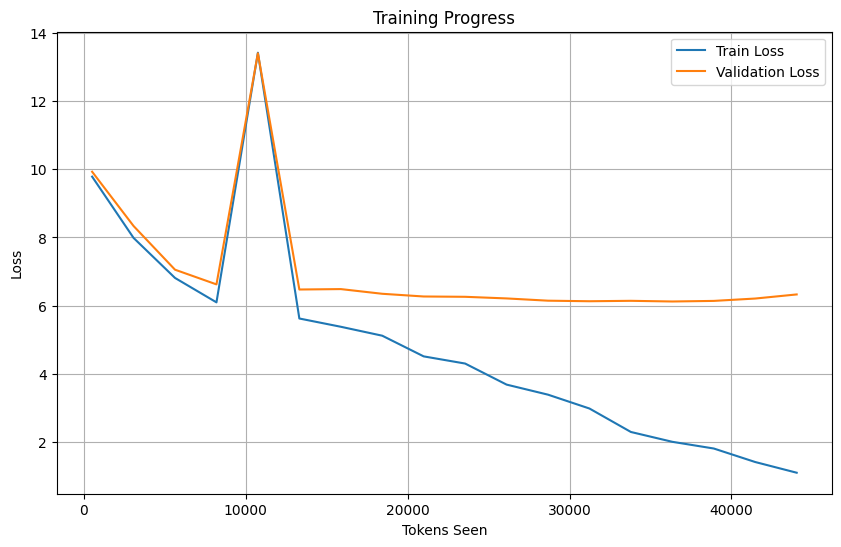

In [23]:
# Visualize training progress
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(tokens_seen, train_losses, label='Train Loss')
plt.plot(tokens_seen, val_losses, label='Validation Loss')
plt.xlabel('Tokens Seen')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True)
plt.show()

### **Text Generation with the Trained Model**

In [24]:
# Generate text with the trained model
torch.manual_seed(123)  # For reproducible generation

# Generate text
generated_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=100,  # Generate 100 new tokens
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,  # Use top-k sampling
    temperature=1.4  # Higher temperature for more creative text
)

# Print the generated text
print("Generated text:")
print(token_ids_to_text(generated_ids, tokenizer))

Generated text:
Every effort moves you get up him. By Jack, and thought one," had the last with a so when hearming, when, at each landing. Poor Jack's sent my on my them out--she--since he was, I--that than he was. Stroud do at that, with the _has to go, he were, the end would a congest. Gisburn's only's career up, all my own no--for it is, I felt was instruct's an, or in the


### **Saving and Loading the Model**

In [25]:
# Save the trained model
torch.save(model.state_dict(), "language_model.pth")

# Create a new model instance and load the saved weights
model2 = LLMModel(GPT_CONFIG_124M)
model2.load_state_dict(torch.load("language_model.pth"))
model2.eval()  # Set to evaluation mode

# Save both model and optimizer states
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    }, 
    "model_and_optimizer.pth"
)

# Load both model and optimizer states
checkpoint = torch.load("model_and_optimizer.pth")
model3 = LLMModel(GPT_CONFIG_124M)
model3.load_state_dict(checkpoint["model_state_dict"])
optimizer3 = torch.optim.AdamW(model3.parameters(), lr=5e-4, weight_decay=0.1)
optimizer3.load_state_dict(checkpoint["optimizer_state_dict"])
model3.train()

LLMModel(
  (token_emb): Embedding(50257, 768)
  (positional_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in